# problem statement

Relation to capstone challenge This problem revolves around multilingual image classification using Neural Networks. Note that this is an important component of sign-board translation which will be the topic for the capstone challenge. Languages and dataset The practice problem has essentially been split into two parts, one part for Tamil character classification and the other for Hindi. The possibility of doing it on two languages ensures that you are able to understand whether models generalise across variations in the dataset. You do not need to be familiar with the script of the languages to attempt the problems. Each image is 64x64 pixels, and contains the character to be classified superimposed over a random scenic background. You will be presented with two training sets of 10,000 images each, for Tamil and Hindi. For each language, we have selected 10 vowels and 10 consonants, and dataset of 10,000 images is made using all possible permutations of vowel-consonant pairs. Model architecture We would recommend you to attempt these for two settings: (a) with only feed forward networks, and (b) with convolutional neural networks. Of course, you would need to try out different hyper-parameters (using MLFlow or equivalent) to obtain the best possible results. Hint You have to classify the text into consonant and vowel. The firs thing therefore is to think about the final layer and the loss function. Here is a quick hint about that. Your neural network needs to be designed such that at the output layer, we have two separate sets of 10 classes, one set for vowels and the other set for consonants with a softmax for each of the two sets as pictured in the image below.

The image shows a diagram of a neural network architecture for classifying 10 classes, split into two sets: vowels and consonants. The workflow is: Input Image → Hidden Layers Hidden layers branch into two separate paths: One path for vowels with dense/linear layers and a softmax output. One path for consonants with dense/linear layers and a softmax output. Each branch produces a log loss (vowels and consonants). The two log losses are summed to form a combined loss. The combined loss is used for backpropagation. Text below the diagram explains that the loss values for vowels and consonants must be summed to compute the combined loss for training.

In [3]:
import torch

print("available:", torch.cuda.is_available())
print("version", torch.version.cuda)
if torch.cuda.is_available():
    print("count", torch.cuda.device_count())
    print("name", torch.cuda.get_device_name(0))


available: True
version 12.9
count 1
name NVIDIA GeForce GTX 1650


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
train_path = "E:/PERSONAL/PROJECT/ofc/data/tamil/train/train"

# Define image transformation
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),  
])

In [8]:
class TamilCharacterDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform
        self.image_files = [f for f in os.listdir(folder_path) if f.endswith('.png')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
   
        img_name = self.image_files[idx]
        img_path = os.path.join(self.folder_path, img_name)
        
        
        image = Image.open(img_path).convert("RGB")
        
        
        if self.transform:
            image = self.transform(image)
        
        # Extract vowel and consonant labels from file name
        # Example: "V3_C5_1.png" → vowel=3, consonant=5
        parts = img_name.split('_')
        vowel = int(parts[0][1:])      
        consonant = int(parts[1][1:])   
        
        return image, torch.tensor(vowel), torch.tensor(consonant)


train_dataset = TamilCharacterDataset(train_path, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Total training images: {len(train_dataset)}")


Total training images: 10000


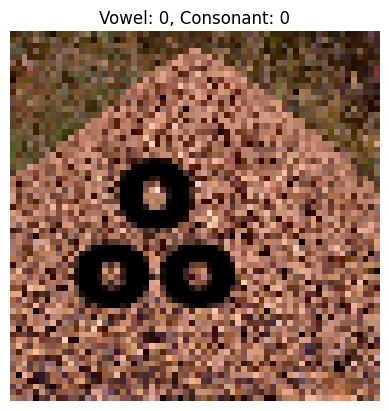

In [9]:
sample_img, vowel_label, consonant_label = train_dataset[0]
plt.imshow(sample_img.permute(1, 2, 0))
plt.title(f"Vowel: {vowel_label}, Consonant: {consonant_label}")
plt.axis('off')
plt.show()

In [13]:
class FNNCharacterClassifier(nn.Module):
    def __init__(self):
        super(FNNCharacterClassifier, self).__init__()
        # Input 64*64*3 = 12288
        self.flatten = nn.Flatten()
        
        # Shared hidden layers
        self.fc1 = nn.Linear(64*64*3, 512)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        
        # Two heads: vowel and consonant
        self.vowel_head = nn.Linear(256, 10)
        self.consonant_head = nn.Linear(256, 10)
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        
        vowel_out = self.vowel_head(x)
        consonant_out = self.consonant_head(x)
        return vowel_out, consonant_out

# Initialize model
model = FNNCharacterClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [14]:
epochs = 30  
for epoch in range(epochs):
    running_loss = 0.0
    for i, (images, vowel_labels, consonant_labels) in enumerate(train_loader):
        images = images.to(device)
        vowel_labels = vowel_labels.to(device)
        consonant_labels = consonant_labels.to(device)
        
        optimizer.zero_grad()
        
        vowel_out, consonant_out = model(images)
        
        loss_vowel = criterion(vowel_out, vowel_labels)
        loss_consonant = criterion(consonant_out, consonant_labels)
        total_loss = loss_vowel + loss_consonant
        
        total_loss.backward()
        optimizer.step()
        
        running_loss += total_loss.item()
        
        if (i+1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], Loss: {running_loss/100:.4f}")
            running_loss = 0.0

Epoch [1/30], Step [100/313], Loss: 4.7488
Epoch [1/30], Step [200/313], Loss: 4.6115
Epoch [1/30], Step [300/313], Loss: 4.6078
Epoch [2/30], Step [100/313], Loss: 4.6054
Epoch [2/30], Step [200/313], Loss: 4.6065
Epoch [2/30], Step [300/313], Loss: 4.6069
Epoch [3/30], Step [100/313], Loss: 4.6049
Epoch [3/30], Step [200/313], Loss: 4.6058
Epoch [3/30], Step [300/313], Loss: 4.6067
Epoch [4/30], Step [100/313], Loss: 4.6057
Epoch [4/30], Step [200/313], Loss: 4.6059
Epoch [4/30], Step [300/313], Loss: 4.6063
Epoch [5/30], Step [100/313], Loss: 4.6057
Epoch [5/30], Step [200/313], Loss: 4.6060
Epoch [5/30], Step [300/313], Loss: 4.6063
Epoch [6/30], Step [100/313], Loss: 4.6055
Epoch [6/30], Step [200/313], Loss: 4.6059
Epoch [6/30], Step [300/313], Loss: 4.6065
Epoch [7/30], Step [100/313], Loss: 4.6052
Epoch [7/30], Step [200/313], Loss: 4.6060
Epoch [7/30], Step [300/313], Loss: 4.6063
Epoch [8/30], Step [100/313], Loss: 4.6053
Epoch [8/30], Step [200/313], Loss: 4.6060
Epoch [8/30

In [15]:
test_path = "E:/PERSONAL/PROJECT/ofc/data/tamil/test/test"
test_images = sorted(os.listdir(test_path), key=lambda x: int(x.split('.')[0]))

# Store predictions
results = []

model.eval() 
with torch.no_grad():
    for img_name in test_images:
        img_path = os.path.join(test_path, img_name)
        image = Image.open(img_path).convert("RGB")
        image = transform(image).unsqueeze(0).to(device)  
        
        vowel_out, consonant_out = model(image)
        
     
        pred_vowel = torch.argmax(vowel_out, dim=1).item()
        pred_consonant = torch.argmax(consonant_out, dim=1).item()
        
        results.append({
            "image": img_name,
            "predicted_class": f"V{pred_vowel}_C{pred_consonant}"
        })


df_results = pd.DataFrame(results)
df_results.head(10)  

,image,predicted_class
0,1.png,V3_C9
1,2.png,V3_C9
2,3.png,V3_C9
3,4.png,V3_C9
4,5.png,V3_C9
5,6.png,V3_C9
6,7.png,V3_C9
7,8.png,V3_C9
8,9.png,V3_C9
9,10.png,V3_C9


In [16]:
model.eval()  

total_vowel = 0
correct_vowel = 0

total_consonant = 0
correct_consonant = 0

total_combined = 0
correct_combined = 0

with torch.no_grad():
    for images, vowel_labels, consonant_labels in train_loader:
        images = images.to(device)
        vowel_labels = vowel_labels.to(device)
        consonant_labels = consonant_labels.to(device)
        
        vowel_out, consonant_out = model(images)
        
        pred_vowel = torch.argmax(vowel_out, dim=1)
        pred_consonant = torch.argmax(consonant_out, dim=1)
        
        # Vowel accuracy
        correct_vowel += (pred_vowel == vowel_labels).sum().item()
        total_vowel += vowel_labels.size(0)
        
        # Consonant accuracy
        correct_consonant += (pred_consonant == consonant_labels).sum().item()
        total_consonant += consonant_labels.size(0)
        
       
        correct_combined += ((pred_vowel == vowel_labels) & (pred_consonant == consonant_labels)).sum().item()
        total_combined += vowel_labels.size(0)

print(f"Vowel Accuracy: {correct_vowel/total_vowel*100:.2f}%")
print(f"Consonant Accuracy: {correct_consonant/total_consonant*100:.2f}%")
print(f"Combined Accuracy: {correct_combined/total_combined*100:.2f}%")


Vowel Accuracy: 10.00%
Consonant Accuracy: 10.00%
Combined Accuracy: 1.00%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Step 1: Define CNN architecture
class CNNCharacterClassifier(nn.Module):
    def __init__(self):
        super(CNNCharacterClassifier, self).__init__()
        # Convolution layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)  # 64x64 -> 32x32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # Fully connected layers
        self.fc1 = nn.Linear(128*8*8, 256)  
        self.relu = nn.ReLU()
        
        # Two heads
        self.vowel_head = nn.Linear(256, 10)
        self.consonant_head = nn.Linear(256, 10)
        
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x))) # 64->32
        x = self.pool(self.relu(self.conv2(x))) # 32->16
        x = self.pool(self.relu(self.conv3(x))) # 16->8
        x = x.view(x.size(0), -1)               # flatten
        x = self.relu(self.fc1(x))
        
        vowel_out = self.vowel_head(x)
        consonant_out = self.consonant_head(x)
        return vowel_out, consonant_out

# Initialize model
model_cnn = CNNCharacterClassifier().to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001)

# Training loop
epochs = 10  
for epoch in range(epochs):
    running_loss = 0.0
    for i, (images, vowel_labels, consonant_labels) in enumerate(train_loader):
        images = images.to(device)
        vowel_labels = vowel_labels.to(device)
        consonant_labels = consonant_labels.to(device)
        
        optimizer.zero_grad()
        
        vowel_out, consonant_out = model_cnn(images)
        loss_vowel = criterion(vowel_out, vowel_labels)
        loss_consonant = criterion(consonant_out, consonant_labels)
        total_loss = loss_vowel + loss_consonant
        
        total_loss.backward()
        optimizer.step()
        
        running_loss += total_loss.item()
        if (i+1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], Loss: {running_loss/100:.4f}")
            running_loss = 0.0


Epoch [1/10], Step [100/313], Loss: 4.6079
Epoch [1/10], Step [200/313], Loss: 4.5103
Epoch [1/10], Step [300/313], Loss: 4.2186
Epoch [2/10], Step [100/313], Loss: 3.6373
Epoch [2/10], Step [200/313], Loss: 3.1651
Epoch [2/10], Step [300/313], Loss: 2.8530
Epoch [3/10], Step [100/313], Loss: 2.3857
Epoch [3/10], Step [200/313], Loss: 2.1750
Epoch [3/10], Step [300/313], Loss: 2.0407
Epoch [4/10], Step [100/313], Loss: 1.6657
Epoch [4/10], Step [200/313], Loss: 1.6183
Epoch [4/10], Step [300/313], Loss: 1.5328
Epoch [5/10], Step [100/313], Loss: 1.2340
Epoch [5/10], Step [200/313], Loss: 1.2455
Epoch [5/10], Step [300/313], Loss: 1.2314
Epoch [6/10], Step [100/313], Loss: 0.9674
Epoch [6/10], Step [200/313], Loss: 0.9406
Epoch [6/10], Step [300/313], Loss: 0.9598
Epoch [7/10], Step [100/313], Loss: 0.7687
Epoch [7/10], Step [200/313], Loss: 0.7783
Epoch [7/10], Step [300/313], Loss: 0.8008
Epoch [8/10], Step [100/313], Loss: 0.6323
Epoch [8/10], Step [200/313], Loss: 0.6444
Epoch [8/10

In [ ]:
test_path = "E:/PERSONAL/PROJECT/ofc/data/tamil/test/test"
test_images = sorted(os.listdir(test_path), key=lambda x: int(x.split('.')[0]))


results = []

model_cnn.eval() 
with torch.no_grad():
    for img_name in test_images:
        img_path = os.path.join(test_path, img_name)
        image = Image.open(img_path).convert("RGB")
        image = transform(image).unsqueeze(0).to(device) 
        
        vowel_out, consonant_out = model_cnn(image)  
        
        pred_vowel = torch.argmax(vowel_out, dim=1).item()
        pred_consonant = torch.argmax(consonant_out, dim=1).item()
        
        results.append({
            "image": img_name,
            "predicted_class": f"V{pred_vowel}_C{pred_consonant}"
        })

df_results = pd.DataFrame(results)
df_results.to_csv("cnn_tamil_test_predictions.csv", index=False)
df_results.head(10)


,image,predicted_class
0,1.png,V4_C2
1,2.png,V0_C0
2,3.png,V0_C0
3,4.png,V0_C1
4,5.png,V8_C0
5,6.png,V0_C0
6,7.png,V8_C0
7,8.png,V0_C0
8,9.png,V4_C1
9,10.png,V0_C0


In [ ]:

model_cnn.eval() 

total_vowel = 0
correct_vowel = 0

total_consonant = 0
correct_consonant = 0

total_combined = 0
correct_combined = 0

with torch.no_grad():
    for images, vowel_labels, consonant_labels in train_loader:  
        images = images.to(device)
        vowel_labels = vowel_labels.to(device)
        consonant_labels = consonant_labels.to(device)
        
        vowel_out, consonant_out = model_cnn(images)
        
        pred_vowel = torch.argmax(vowel_out, dim=1)
        pred_consonant = torch.argmax(consonant_out, dim=1)
        
        # Vowel accuracy
        correct_vowel += (pred_vowel == vowel_labels).sum().item()
        total_vowel += vowel_labels.size(0)
        
        # Consonant accuracy
        correct_consonant += (pred_consonant == consonant_labels).sum().item()
        total_consonant += consonant_labels.size(0)
        
        # Combined accuracy (both correct)
        correct_combined += ((pred_vowel == vowel_labels) & (pred_consonant == consonant_labels)).sum().item()
        total_combined += vowel_labels.size(0)

# Print accuracies
print(f"CNN Vowel Accuracy: {correct_vowel/total_vowel*100:.2f}%")
print(f"CNN Consonant Accuracy: {correct_consonant/total_consonant*100:.2f}%")
print(f"CNN Combined Accuracy: {correct_combined/total_combined*100:.2f}%")


CNN Vowel Accuracy: 92.96%
CNN Consonant Accuracy: 94.33%
CNN Combined Accuracy: 89.61%
